<a href="https://colab.research.google.com/github/Anisha32414/Deep-Learning/blob/main/ANN_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install tensorflow

In [5]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
## import some basic lib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [8]:
dataset=pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
## divide the dataset into dependent and independent features
x=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]


In [10]:
x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [12]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [24]:
## Feature Engineering
geography=pd.get_dummies(x['Geography'],drop_first=True)
gender=pd.get_dummies(x['Gender'],drop_first=True)

KeyError: 'Geography'

In [16]:
gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [22]:
## Concatenate these variables with dataframes
x=x.drop(['Geography','Gender'],axis=1)

KeyError: "['Geography', 'Gender'] not found in axis"

In [25]:
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [28]:
x=pd.concat([x,geography,gender],axis=1)

In [29]:
## Splitting the dataset into Training set and Testing set
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [30]:
## Feature Scaling
from sklearn.preprocessing import  StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [31]:
x_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [32]:
x_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [33]:
x_train.shape

(8000, 14)

In [35]:
## 2nd part --->> Creating ANN

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout


In [40]:
## Lets initialize the ANN
classifier=Sequential()

In [41]:
## Adding input layer
classifier.add(Dense(units=11,activation='relu'))


In [43]:
## Adding 1st hidden layer
classifier.add(Dense(units=7,activation='relu'))

In [44]:
## Adding 2nd hidden layer
classifier.add(Dense(units=6,activation='relu'))

In [46]:
## Adding output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [47]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [49]:
## early stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [50]:
model_history=classifier.fit(x_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8690 - loss: 0.3159 - val_accuracy: 0.8573 - val_loss: 0.3601
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8711 - loss: 0.3161 - val_accuracy: 0.8569 - val_loss: 0.3614
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8722 - loss: 0.3151 - val_accuracy: 0.8554 - val_loss: 0.3625
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8703 - loss: 0.3153 - val_accuracy: 0.8561 - val_loss: 0.3608
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8718 - loss: 0.3146 - val_accuracy: 0.8569 - val_loss: 0.3608
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8709 - loss: 0.3146 - val_accuracy: 0.8504 - val_loss: 0.3723
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8720 - loss: 0.3144 - val_accuracy: 0.8557 - val_loss: 0.3622
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8707 - loss: 0.3146 - 

In [52]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

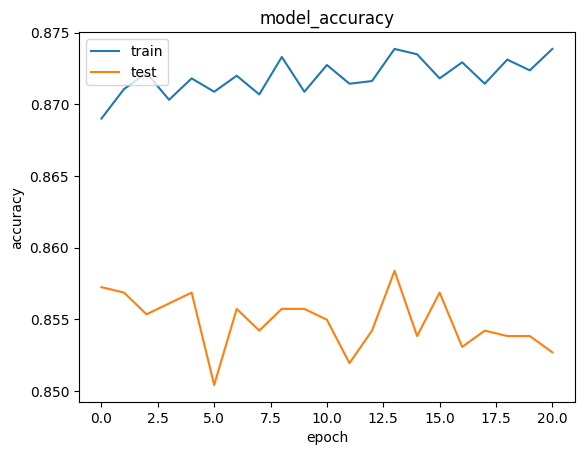

In [53]:
## Summary history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model_accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

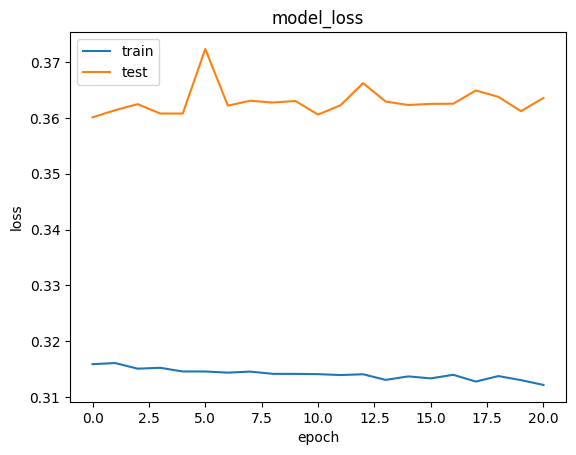

In [54]:
## Summary history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model_loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [55]:
## Part 3 - Making the predictions and evaluating the model

# Predict the test set result

y_pred=classifier.predict(x_test)
y_pred=(y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [56]:
## Make the confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)

cm

array([[1516,   79],
       [ 200,  205]])

In [60]:
## Calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

score

0.8605

In [62]:
## get the weights
classifier.get_weights()

[array([[ 0.00383724, -0.01506422,  0.56153536,  0.15007704, -0.22437325,
          0.04477749,  0.15579744,  0.09766179, -0.14738424,  0.28185248,
          0.39755753],
        [ 0.9210747 , -0.4385272 ,  0.4405461 , -0.8527262 ,  0.740443  ,
         -0.3015681 ,  0.76196665, -0.7770137 , -0.35553676, -0.6436555 ,
         -0.1933396 ],
        [-0.03944277, -0.8085462 ,  0.1864722 , -0.1620907 , -0.15781063,
          0.3139054 ,  0.33381447,  0.53192264,  0.5148524 , -0.19059144,
          0.08527584],
        [-0.36756113, -0.4613754 , -0.6480783 , -0.03833994,  0.3459659 ,
         -0.45163628,  0.0104755 ,  0.33894774, -0.46676737, -0.40292054,
          0.54981595],
        [-0.8966458 , -0.04525672, -0.18917003,  0.45114717, -0.11252104,
         -0.09122027,  1.0790216 , -0.03442843, -0.06227804,  0.61896753,
         -0.30499566],
        [ 0.03870517,  0.4947348 , -0.04050394, -0.13826619,  0.16937311,
         -0.15760101,  0.02614876,  0.29630655, -0.02265495,  0.1657181